# Treinamento dos Modelos Baseline: MLP e VGG no CIFAR-10

Este notebook implementa o treinamento completo e a avaliação dos modelos baseline **CIFAR10MLP** (totalmente conectado) e **CIFAR10VGG** (convolucional profundo) utilizando o dataset CIFAR-10.

**Objetivos:**
1. Carregar a divisão determinística de treino/validação gerada anteriormente (`data/cifar10_split.pt`).
2. Instanciar e treinar os baselines MLP e VGG até a convergência utilizando o otimizador Adam.
3. Avaliar os baselines treinados no conjunto de teste oficial usando métricas de classificação detalhadas (acurácia, precisão, sensibilidade, F1-score).
4. Salvar os modelos na pasta `model_dir/` para servir como pontos de partida nos pipelines de compressão por poda (pruning) subsequentes.

## 1. Configuração e Importações

Carregamos as bibliotecas do PyTorch e importamos as classes de rede (`CIFAR10MLP`, `CIFAR10VGG`) e funções de treinamento e avaliação a partir do arquivo modular `utils.py`.

In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path
from torch.utils.data import DataLoader, Subset

# Importar modelos e rotinas de utils.py
from utils import (
    CIFAR10MLP,
    CIFAR10VGG,
    train_model,
    evaluate_model,
    compute_metrics,
    classes
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo ativo: {device}")

# Garantir reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Dispositivo ativo: cpu


## 2. Carregamento de Dados e Split Determinístico

Recuperamos a divisão determinística treino/validação que salvamos no disco anteriormente para garantir consistência em todos os treinamentos e podas futuras.

In [2]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

full_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

# Recarregar divisão original
split = torch.load("data/cifar10_split.pt", weights_only=False)
train_indices = split["train_indices"]
val_indices = split["val_indices"]

trainset = Subset(full_trainset, train_indices)
valset = Subset(full_trainset, val_indices)

batch_size = 64
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Treino: {len(trainset):,} | Validação: {len(valset):,} | Teste: {len(testset):,}")

Treino: 42,500 | Validação: 7,500 | Teste: 10,000


## 3. Treinamento da Rede Totalmente Conectada (CIFAR10MLP)

O modelo MLP possui camadas lineares densas que serão podadas posteriormente. Treinamos este modelo baseline por 15 épocas.

In [3]:
mlp_model = CIFAR10MLP()
print(mlp_model)
print(f"Total de parâmetros ativos: {sum(p.numel() for p in mlp_model.parameters()):,}")

# Treinar o modelo baseline
print("\nIniciando treinamento do baseline MLP...")
mlp_model, mlp_train_losses, mlp_val_losses, mlp_val_accuracies = train_model(
    mlp_model,
    trainloader,
    valloader,
    epochs=15,
    lr=1e-3
)

CIFAR10MLP(
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=2048, bias=True)
    (2): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=2048, out_features=1024, bias=True)
    (6): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=1024, out_features=512, bias=True)
    (10): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.2, inplace=False)
    (13): Linear(in_features=512, out_features=10, bias=True)
  )
)
Total de parâmetros ativos: 8,928,778

Iniciando treinamento do baseline MLP...


100%|██████████| 665/665 [00:32<00:00, 20.17it/s]


Epoch [1/15] Train Loss: 1.7042 | Val Loss: 1.5283 | Val Acc: 46.08%


100%|██████████| 665/665 [00:33<00:00, 19.64it/s]


Epoch [2/15] Train Loss: 1.5035 | Val Loss: 1.4569 | Val Acc: 47.45%


...

Epoch [13/15] Train Loss: 0.9601 | Val Loss: 1.2541 | Val Acc: 57.76%


100%|██████████| 665/665 [00:35<00:00, 18.65it/s]


Epoch [14/15] Train Loss: 0.9186 | Val Loss: 1.2717 | Val Acc: 57.15%


100%|██████████| 665/665 [00:35<00:00, 18.50it/s]


Epoch [15/15] Train Loss: 0.8822 | Val Loss: 1.2753 | Val Acc: 57.24%


### Avaliação do Baseline MLP

Avaliamos o modelo treinado no conjunto de teste e salvamos seus pesos em `model_dir/cifar_mlp.pt`.

In [4]:
models_dir = Path('model_dir')
models_dir.mkdir(exist_ok=True)

torch.save(mlp_model, models_dir / 'cifar_mlp.pt')
print("Modelo MLP salvo com sucesso em model_dir/cifar_mlp.pt")

# Obter métricas de teste
y_true, y_pred, y_probs = evaluate_model(mlp_model, testloader, device)
mlp_metrics = compute_metrics(y_true, y_pred)

print("\nMétricas de Teste do MLP Baseline:")
for metric_name, score in mlp_metrics.items():
    print(f"  {metric_name:<20}: {score:.4f}")

Modelo MLP salvo com sucesso em model_dir/cifar_mlp.pt

Métricas de Teste do MLP Baseline:
  accuracy            : 0.5726
  balanced_accuracy   : 0.5726
  precision_macro     : 0.5722
  precision_weighted  : 0.5722
  recall_macro        : 0.5726
  recall_weighted     : 0.5726
  f1_macro            : 0.5708
  f1_weighted         : 0.5708
  cohen_kappa         : 0.5251
  mcc                 : 0.5255


## 4. Treinamento da Rede Convolucional Profunda (CIFAR10VGG)

A VGG-11 modificada é ideal para testes de poda estrutural de canais convolucionais (filtros) devido à sua alta complexidade de parâmetros. Treinamos o baseline convolucional.

In [5]:
vgg_model = CIFAR10VGG()
print(vgg_model)
print(f"Total de parâmetros ativos: {sum(p.numel() for p in vgg_model.parameters()):,}")

# Treinar o modelo baseline
print("\nIniciando treinamento do baseline VGG...")
vgg_model, vgg_train_losses, vgg_val_losses, vgg_val_accuracies = train_model(
    vgg_model,
    trainloader,
    valloader,
    epochs=15,
    lr=1e-3
)

CIFAR10VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)


100%|██████████| 665/665 [04:46<00:00,  2.32it/s]


Epoch [1/15] Train Loss: 1.5743 | Val Loss: 1.3177 | Val Acc: 51.53%


100%|██████████| 665/665 [04:04<00:00,  2.72it/s]


Epoch [2/15] Train Loss: 1.1320 | Val Loss: 1.0046 | Val Acc: 64.44%


...

Epoch [13/15] Train Loss: 0.1465 | Val Loss: 0.8018 | Val Acc: 80.48%


100%|██████████| 665/665 [04:00<00:00,  2.76it/s]


Epoch [14/15] Train Loss: 0.1265 | Val Loss: 0.8888 | Val Acc: 80.99%


100%|██████████| 665/665 [04:07<00:00,  2.69it/s]


Epoch [15/15] Train Loss: 0.1137 | Val Loss: 0.8105 | Val Acc: 81.87%


### Avaliação do Baseline VGG

Avaliamos o modelo convolucional treinado no conjunto de teste e salvamos em `model_dir/cifar_vgg.pt`.

In [6]:
torch.save(vgg_model, models_dir / 'cifar_vgg.pt')
print("Modelo VGG salvo com sucesso em model_dir/cifar_vgg.pt")

# Obter métricas de teste
y_true, y_pred, y_probs = evaluate_model(vgg_model, testloader, device)
vgg_metrics = compute_metrics(y_true, y_pred)

print("\nMétricas de Teste do VGG Baseline:")
for metric_name, score in vgg_metrics.items():
    print(f"  {metric_name:<20}: {score:.4f}")

Modelo VGG salvo com sucesso em model_dir/cifar_vgg.pt

Métricas de Teste do VGG Baseline:
  accuracy            : 0.8113
  balanced_accuracy   : 0.8113
  precision_macro     : 0.8161
  precision_weighted  : 0.8161
  recall_macro        : 0.8113
  recall_weighted     : 0.8113
  f1_macro            : 0.8110
  f1_weighted         : 0.8110
  cohen_kappa         : 0.7903
  mcc                 : 0.7909


## 5. Comparação

Comparamos quantitativamente as métricas de ambos os modelos baseline e plotamos as curvas de perda (loss) de treinamento e validação para analisar o comportamento da convergência.


Tabela Comparativa de Métricas no Teste:


,MLP Baseline,VGG Baseline
accuracy,0.572600,0.811300
balanced_accuracy,0.572600,0.811300
precision_macro,0.572232,0.816118
precision_weighted,0.572232,0.816118
recall_macro,0.572600,0.811300
recall_weighted,0.572600,0.811300
f1_macro,0.570818,0.810954
f1_weighted,0.570818,0.810954
cohen_kappa,0.525111,0.790333
mcc,0.525454,0.790913


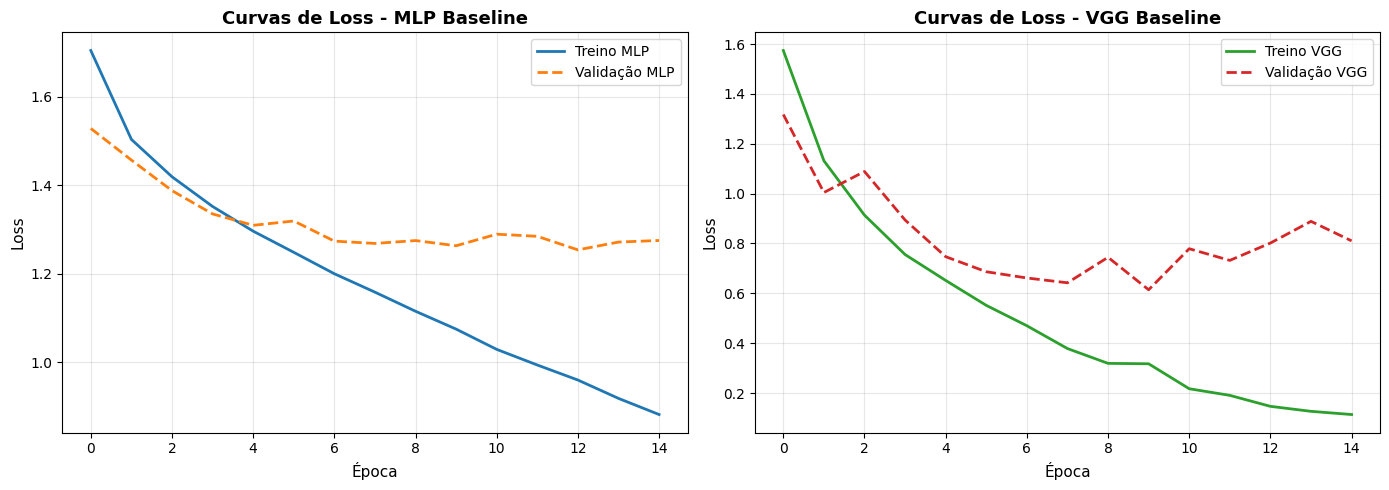

In [7]:
import pandas as pd

# Criar DataFrame de comparação
comparison_df = pd.DataFrame({
    "MLP Baseline": mlp_metrics,
    "VGG Baseline": vgg_metrics
})

print("\nTabela Comparativa de Métricas no Teste:")
display(comparison_df)

# Plotar perdas
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(mlp_train_losses, label="Treino MLP", color="#1F77B4", linewidth=2)
plt.plot(mlp_val_losses, label="Validação MLP", color="#FF7F0E", linestyle="--", linewidth=2)
plt.title("Curvas de Loss - MLP Baseline", fontsize=13, fontweight='bold')
plt.xlabel("Época", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(vgg_train_losses, label="Treino VGG", color="#2CA02C", linewidth=2)
plt.plot(vgg_val_losses, label="Validação VGG", color="#D62728", linestyle="--", linewidth=2)
plt.title("Curvas de Loss - VGG Baseline", fontsize=13, fontweight='bold')
plt.xlabel("Época", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()